# 1. Prediction Curve (Regression Equivalent of Decision Boundary)

> **Note:** Polynomial Regression is a **regression algorithm**, so it does **not** have a decision boundary. Instead, we visualize the **prediction curve**.

---

## Visualization 1: Data + Polynomial Curve

## Code Explanation

### Step 1

```python
X = np.array([1,2,3,4,5,6]).reshape(-1,1)
```

Creates one input feature with shape `(6,1)`.

---

### Step 2

```python
poly = PolynomialFeatures(degree=2, include_bias=False)
```

Creates a transformer that will convert:

```
x
```

into

```
x
x²
```

---

### Step 3

```python
X_poly = poly.fit_transform(X)
```

Transforms the original feature matrix.

Example:

| Original | After Transformation |
| -------- | -------------------- |
| 1        | 1, 1                 |
| 2        | 2, 4                 |
| 3        | 3, 9                 |

---

### Step 4

```python
model.fit(X_poly, y)
```

Trains a Linear Regression model on the transformed features.

The learned equation is of the form:

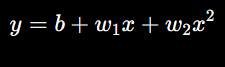

---

### Step 5

```python
x_plot = np.linspace(1,6,100).reshape(-1,1)
```

Generates **100 evenly spaced x-values** between 1 and 6.

This is done **only to draw a smooth curve**. It does not affect training.

---

### Step 6

```python
x_plot_poly = poly.transform(x_plot)
```

Transforms these 100 points into polynomial features so the model can make predictions.

---

### Step 7

```python
y_plot = model.predict(x_plot_poly)
```

Predicts the output for all 100 points.

---

### Step 8

```python
plt.scatter(X, y, ...)
```

Plots the original training data as blue dots.

---

### Step 9

```python
plt.plot(x_plot, y_plot, ...)
```

Plots the predicted polynomial curve in red.

---

## Interpretation

You will see:

* **Blue dots** → Actual data
* **Red curve** → Model prediction

The red curve bends to fit the data instead of remaining a straight line.

---

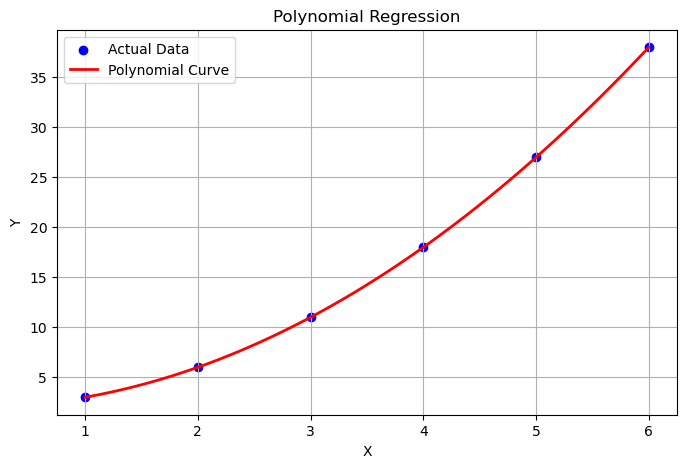

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Sample Data
X = np.array([1,2,3,4,5,6]).reshape(-1,1)
y = np.array([3,6,11,18,27,38])

# Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train Model
model = LinearRegression()
model.fit(X_poly, y)

# Smooth Curve
x_plot = np.linspace(1,6,100).reshape(-1,1)
x_plot_poly = poly.transform(x_plot)
y_plot = model.predict(x_plot_poly)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(x_plot, y_plot, color="red", linewidth=2, label="Polynomial Curve")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression")
plt.legend()
plt.grid(True)
plt.show()

# 2. Effect of Hyperparameters (Degree)

This is the **most important visualization**.

It shows how increasing the polynomial degree changes the fitted curve.

---
---

# Interpretation

### Degree = 1

```text
Straight line
```

* High Bias
* Underfitting

---

### Degree = 2

```text
Nice smooth curve
```

Usually the best choice.

---

### Degree = 3

```text
More flexible curve
```

Can capture more complex relationships.

---

### Degree = 5

```text
Very wiggly curve
```

Begins fitting noise.

Risk of overfitting.

---

## What are we learning?

Increasing the degree

↓

More polynomial features

↓

Higher flexibility

↓

Eventually overfitting

---

# Code Explanation

## Step 1

```python
degrees = [1,2,3,5]
```

Instead of training **one** Polynomial Regression model, we're training **four different models**.

| Degree | Model                 |
| ------ | --------------------- |
| 1      | Linear Regression     |
| 2      | Quadratic Polynomial  |
| 3      | Cubic Polynomial      |
| 5      | 5th Degree Polynomial |

We want to compare how the curve changes as the degree increases.

---

## Step 2

```python
plt.figure(figsize=(12,8))
```

Creates one large figure that will contain all four graphs.

Without this, each graph would appear in a separate window.

---

## Step 3

```python
for i, degree in enumerate(degrees):
```

This loop runs **four times**.

### Iteration 1

```python
i = 0
degree = 1
```

### Iteration 2

```python
i = 1
degree = 2
```

### Iteration 3

```python
i = 2
degree = 3
```

### Iteration 4

```python
i = 3
degree = 5
```

So each iteration trains a completely new Polynomial Regression model.

---

## Step 4

```python
poly = PolynomialFeatures(
    degree=degree,
    include_bias=False
)
```

Notice something important.

This line changes every iteration.

### First iteration

```python
PolynomialFeatures(degree=1)
```

Creates

```text
x
```

---

### Second iteration

```python
PolynomialFeatures(degree=2)
```

Creates

```text
x
x²
```

---

### Third iteration

```python
PolynomialFeatures(degree=3)
```

Creates

```text
x
x²
x³
```

---

### Fourth iteration

```python
PolynomialFeatures(degree=5)
```

Creates

```text
x
x²
x³
x⁴
x⁵
```

So the only thing changing is **the number of generated features**.

---

## Step 5

```python
X_poly = poly.fit_transform(X)
```

Transforms the training data according to the current degree.

For degree 5,

```text
1

↓

1
1²
1³
1⁴
1⁵
```

---

## Step 6

```python
model = LinearRegression()
model.fit(X_poly,y)
```

Trains a fresh Linear Regression model.

Remember,

Every loop creates a **new model**.

Otherwise, the previous model would be reused.

---

## Step 7

```python
x_plot = np.linspace(1,6,100).reshape(-1,1)
```

Creates 100 x-values for plotting a smooth curve.

Exactly the same purpose as in Visualization 1.

---

## Step 8

```python
x_plot_poly = poly.transform(x_plot)
```

Transforms those 100 points using the **current degree**.

For example:

If the current degree is 3,

every point becomes

```text
x
x²
x³
```

---

## Step 9

```python
y_plot = model.predict(x_plot_poly)
```

Predicts 100 y-values for the smooth curve.

---

## Step 10

```python
plt.subplot(2,2,i+1)
```

This is the only new line compared to the previous visualization.

It divides the figure into a **2 × 2 grid**.

```
-------------
| 1 | 2 |
-------------
| 3 | 4 |
-------------
```

Each iteration draws in one of these four positions.

| Iteration | Position     |
| --------- | ------------ |
| 1         | Top Left     |
| 2         | Top Right    |
| 3         | Bottom Left  |
| 4         | Bottom Right |

---

## Step 11

```python
plt.scatter(X,y)
```

Plots the original dataset.

The same blue points appear in every graph.

---

## Step 12

```python
plt.plot(x_plot,y_plot)
```

Plots the prediction curve for the current degree.

Each subplot will have a different curve.

---

## Step 13

```python
plt.title(f"Degree = {degree}")
```

Displays

```
Degree = 1
```

or

```
Degree = 2
```

etc.

This helps compare the models.

---

## Step 14

```python
plt.tight_layout()
```

Automatically adjusts spacing so the graphs don't overlap.

---

## What Should You Learn From This Graph?

This visualization answers one of the most important questions in Polynomial Regression:

> **How does changing the degree affect the model?**

After seeing this graph, you should be able to identify:

* **Degree = 1** → Underfitting (too simple)
* **Degree = 2 or 3** → Good balance between flexibility and generalization
* **Very high degree (e.g., 5 here)** → Begins overfitting by following noise rather than the true trend

This is exactly why the **degree** is considered the most important hyperparameter in Polynomial Regression.


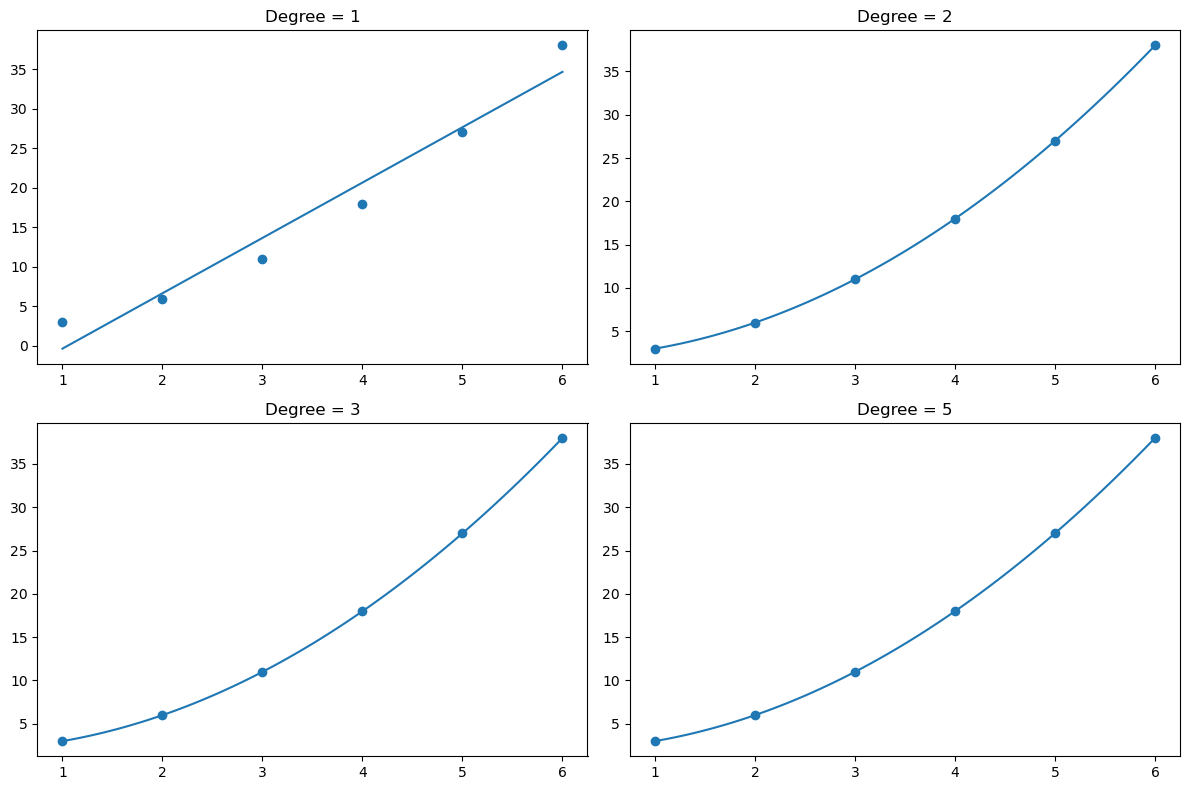

In [3]:
degrees = [1,2,3,5]

plt.figure(figsize=(12,8))

for i, degree in enumerate(degrees):

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    x_plot = np.linspace(1,6,100).reshape(-1,1)
    x_plot_poly = poly.transform(x_plot)

    y_plot = model.predict(x_plot_poly)

    plt.subplot(2,2,i+1)

    plt.scatter(X,y)
    plt.plot(x_plot,y_plot)

    plt.title(f"Degree = {degree}")

plt.tight_layout()
plt.show()

# 3. Learning Curve

This graph helps answer:

> **Is my model underfitting or overfitting?**

Unlike the previous graph, which compared different degrees, this graph shows **how the model's performance changes as we increase the amount of training data**.

---

# Interpretation

### Good Model

```text
Training
────────────

Validation
───────────
```

The two curves become close together.

The model generalizes well.

---

### Underfitting

```text
Training
──────

Validation
─────
```

Both scores remain low.

The model is too simple.

---

### Overfitting

```text
Training
──────────────

Validation
──────
```

Training score is very high, but validation score is much lower.

The gap indicates overfitting.

---

# What is this graph actually showing?

The previous graph answered:

> **"What happens if I change the degree?"**

This graph answers:

> **"What happens if I increase the amount of training data?"**

Instead of changing the model,

we keep the **same model** (degree = 2),

and change only

```text
Training Size
```

---

Suppose your dataset has

```text
100 samples
```

The learning curve trains the model several times.

Example:

| Training Samples Used |
| --------------------- |
| 10                    |
| 20                    |
| 40                    |
| 60                    |
| 80                    |

Each time,

it calculates

* Training Score
* Validation Score

and plots them.

---

# Code Explanation

## Step 1

```python
from sklearn.pipeline import Pipeline
```

We use a Pipeline because Polynomial Regression has two steps:

```text
Polynomial Features
        ↓
Linear Regression
```

Instead of writing both separately every time,

Pipeline combines them into one model.

---

## Step 2

```python
pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("model", LinearRegression())
])
```

This creates a complete model.

Internally it works like

```text
Input Data

↓

Polynomial Features

↓

Linear Regression

↓

Prediction
```

---

## Step 3

```python
learning_curve(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)
```

This is the most important function.

Many students think it trains the model once.

It actually trains the model **many times**.

---

Suppose

```text
100 samples
```

Internally it does something like

| Training Samples | Validation Samples |
| ---------------- | ------------------ |
| 10               | Remaining          |
| 30               | Remaining          |
| 50               | Remaining          |
| 70               | Remaining          |
| 90               | Remaining          |

For each size,

it performs

```text
5-Fold Cross Validation
```

because

```python
cv = 5
```

So the model is trained many times to estimate how performance changes with more data.

---

## Step 4

```python
train_sizes
```

This stores

```text
[10
20
40
60
80]
```

(Actual values depend on dataset size.)

These become the x-axis.

---

## Step 5

```python
train_scores
```

Example

```text
[[0.99 0.98 0.99 0.98 0.99]

 [0.98 0.97 0.99 0.98 0.98]

 ...
]
```

Each row corresponds to one training size.

Each column corresponds to one CV fold.

Shape

```text
(Number of Training Sizes, Number of Folds)
```

---

## Step 6

```python
val_scores
```

Exactly the same structure,

but these are the validation scores instead of training scores.

---

## Step 7

```python
train_mean = train_scores.mean(axis=1)
```

Why do we take the mean?

Suppose

For one training size,

we got

```text
Fold 1 → 0.91

Fold 2 → 0.88

Fold 3 → 0.90

Fold 4 → 0.89

Fold 5 → 0.92
```

Instead of plotting five separate lines,

we compute

```text
Average

0.90
```

One point on the training curve.

---

The same is done for

```python
val_mean = val_scores.mean(axis=1)
```

---

## Step 8

```python
plt.plot(train_sizes, train_mean)
```

Plots

```text
Training Size

↓

Average Training Score
```

---

## Step 9

```python
plt.plot(train_sizes, val_mean)
```

Plots

```text
Training Size

↓

Average Validation Score
```

Now we can compare both curves.

---

# How to Interpret Every Possible Graph

## Case 1 — Good Model ✅

```text
Score

1.0 |---------------- Train
    |              /
0.9 |------------/
    |
0.8 |
    +-------------------------
      Training Size
```

The curves become close together.

Interpretation:

* Model generalizes well.
* No serious overfitting.
* No serious underfitting.

---

## Case 2 — Underfitting

```text
Score

0.7 |---------
    |
0.6 |--------
    |
0.5 |
    +-------------------------
```

Both curves remain low.

Interpretation:

* Model is too simple.
* Degree may be too low.
* Need a more flexible model.

---

## Case 3 — Overfitting

```text
Score

1.0 |---------------- Train

0.8 |

0.6 |--------- Validation

    +-------------------------
```

Large gap between the curves.

Interpretation:

* Model memorizes training data.
* Doesn't generalize well.
* Reduce degree or use Ridge Regression.

---

# What Should You Learn From This Graph?

This graph tells you whether adding more training data is likely to help and whether your current model is suffering from **high bias (underfitting)** or **high variance (overfitting)**.

In real ML projects, the learning curve is one of the first diagnostic plots people use when a model performs poorly, because it helps decide **whether to collect more data or change the model itself**.


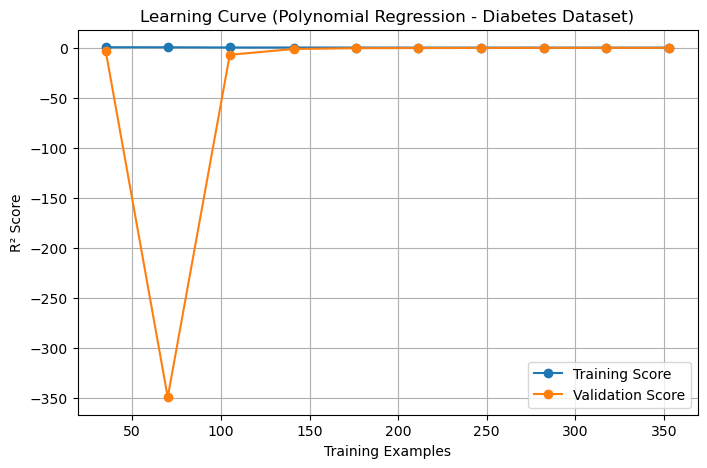

In [5]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Load Dataset
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

# Pipeline
pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Average scores across folds
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation Score"
)

plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.title("Learning Curve (Polynomial Regression - Diabetes Dataset)")

plt.legend()
plt.grid(True)

plt.show()

# 4. Coefficient Analysis

This graph shows the importance (magnitude) of each learned coefficient.

---

# Interpretation

Suppose the graph shows:

| Feature  | Coefficient |
| -------- | ----------- |
| bmi      | 520         |
| bp       | 220         |
| bmi²     | 180         |
| bmi × bp | 90          |

This means

```text
Prediction depends mostly on

bmi

and

bmi²
```

If a coefficient is near zero,

that feature contributes very little.

---

### Important Note

Unlike Decision Trees or Random Forests,

these coefficients are **not** feature importance scores.

They only indicate how strongly each generated feature contributes to the prediction.

---

# Code Explanation

## Step 1

```python
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target
```

Loads the Diabetes dataset.

Original features are

```text
age
sex
bmi
bp
s1
s2
s3
s4
s5
s6
```

There are **10 original features**.

---

## Step 2

```python
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)
```

Creates polynomial features.

The 10 original features become **65 features**.

These include:

```text
age
sex
bmi
...

age²
sex²
bmi²
...

age × bmi
age × bp
...
```

---

## Step 3

```python
X_poly = poly.fit_transform(X)
```

Actually generates all 65 features.

The shape changes from

```text
(442,10)
```

to

```text
(442,65)
```

You can verify it by printing:

```python
print(X.shape)
print(X_poly.shape)
```

Output

```text
(442,10)

(442,65)
```

---

## Step 4

```python
model = LinearRegression()

model.fit(X_poly, y)
```

Trains Linear Regression using all 65 generated features.

The model learns

```text
65 coefficients

+

1 intercept
```

---

## Step 5

```python
feature_names = poly.get_feature_names_out(X.columns)
```

Without this,

the x-axis would simply show

```text
0

1

2

3
...
64
```

Instead,

we obtain meaningful labels such as

```text
age

bmi

bp

bmi²

bp²

bmi bp

...
```

This makes the graph interpretable.

---

## Step 6

```python
plt.bar(feature_names, model.coef_)
```

Creates a bar for **every generated feature**.

Height of each bar = coefficient learned by Linear Regression.

Positive coefficient

```text
↑
```

Negative coefficient

```text
↓
```

---

## Step 7

```python
plt.xticks(rotation=90)
```

There are 65 feature names.

If we keep them horizontal,

they overlap.

Rotating them by 90° makes them readable.

---

## How to Interpret the Graph

Suppose you see

```text
bmi          █████████████

bp           ██████

bmi²         █████

age²         █

sex²         █
```

This means

* **bmi** has the strongest positive influence.
* **bp** also contributes significantly.
* **bmi²** indicates a non-linear relationship involving BMI.
* **age²** has a relatively small contribution.

---

## What if a coefficient is negative?

Example

```text
bmi²      █████

bp²       ▼▼▼▼▼
```

A **negative coefficient** means:

> As that polynomial feature increases, it tends to **decrease the predicted target**, assuming the other features remain constant.

It **does not** mean the feature is "bad" or "unimportant."

---

## Very Important Interview Question

### Why are some coefficients extremely large?

Polynomial features are often **highly correlated**.

Example:

```text
bmi

bmi²

bmi³
```

These features contain similar information.

This causes **multicollinearity**.

As a result, Ordinary Least Squares may assign very large positive and negative coefficients while still making good predictions.

This is one of the biggest reasons we often use:

```text
Polynomial Features
        +
Ridge Regression
```

instead of

```text
Polynomial Features
        +
Linear Regression
```

because Ridge stabilizes the coefficients.

---

# What Should You Learn From This Graph?

This graph helps you answer:

* Which polynomial terms contribute the most to the prediction?
* Which interaction terms are influential?
* Are any coefficients unusually large (possible multicollinearity)?
* Should you consider using Ridge Regression to stabilize the model?

In practice, this visualization is **more useful for understanding the model** than for measuring true feature importance.


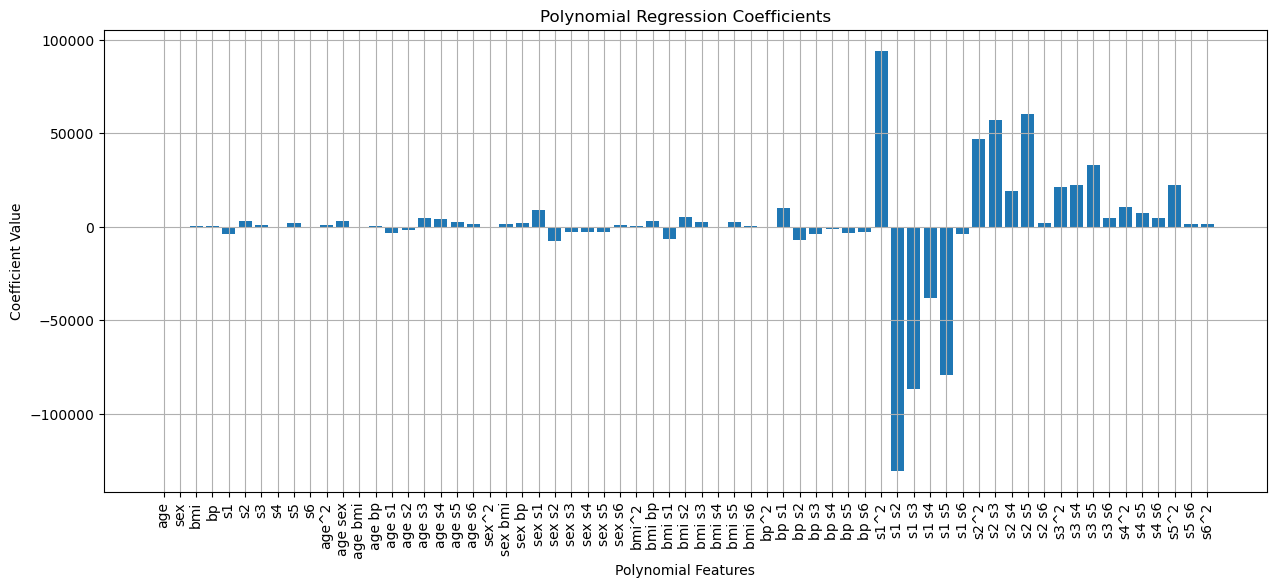

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Load Dataset
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

# Polynomial Features
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(X)

# Train Model
model = LinearRegression()
model.fit(X_poly, y)

# Feature Names
feature_names = poly.get_feature_names_out(X.columns)

# Plot
plt.figure(figsize=(15,6))

plt.bar(feature_names, model.coef_)

plt.xticks(rotation=90)

plt.xlabel("Polynomial Features")
plt.ylabel("Coefficient Value")
plt.title("Polynomial Regression Coefficients")

plt.grid(True)

plt.show()

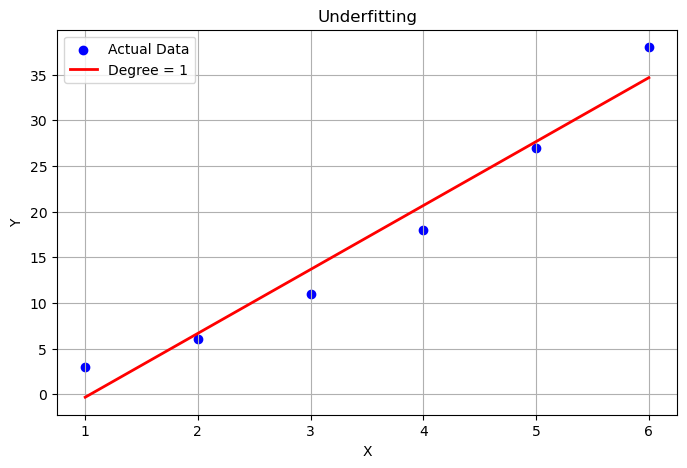

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Sample Data
X = np.array([1,2,3,4,5,6]).reshape(-1,1)
y = np.array([3,6,11,18,27,38])

# Degree = 1 (Linear Regression)
poly = PolynomialFeatures(degree=1, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Smooth Curve
x_plot = np.linspace(1,6,100).reshape(-1,1)
x_plot_poly = poly.transform(x_plot)
y_plot = model.predict(x_plot_poly)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(x_plot, y_plot, color="red", linewidth=2, label="Degree = 1")

plt.title("Underfitting")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()